In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
dataset1 = pd.read_csv("synthetic_user_sessions.csv")
dataset2 = pd.read_csv("all_churn_users.csv")

In [4]:
new_dataset = pd.concat([dataset1, dataset2], ignore_index=True)

In [5]:
new_dataset.tail()

,session_frequency,session_duration,messages_sent,days_since_last,start_emotion,end_emotion,churn
9995,1,3.403983,3,5.031797,3,3,1
9996,2,3.499823,3,6.570550,3,3,1
9997,2,2.775773,3,2.000000,3,3,1
9998,3,4.733929,5,2.000000,1,1,1
9999,0,8.113324,2,14.000000,2,2,1


In [6]:
X = new_dataset.drop(["churn"], axis="columns")
y = new_dataset["churn"]

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Standardization of data

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Building a neural network model via pytorch

In [9]:
import torch
from torch import nn

In [10]:
epochs_list = []
train_loss_list = []
test_loss_list = []

In [11]:
class DropoutChurnModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(6, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)



In [12]:
model = DropoutChurnModel()
model

DropoutChurnModel(
  (model): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)

### Assigning the loss and optimizer functions

In [13]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) #Optimizer function's inputs are weights, biases and learning rate.
loss = nn.BCEWithLogitsLoss()

### Turn the dataframe into tensors

In [14]:
X_train_Tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_Tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(dim=1) # Unsqueezed to match the training data.
X_test_Tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_Tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(dim=1)
X_train_Tensor.dtype


torch.float32

In [15]:
print(y_train_Tensor.shape)
print(y_train_Tensor[:10])
print(y_train_Tensor.unique())

torch.Size([8000, 1])
tensor([[1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.]])
tensor([0., 1.])


### Building a training and testing loop

In [16]:
epochs = 1000

for epoch in range(epochs + 1):
    # Training phase
    model.train()

    train_pred = model(X_train_Tensor) # The inputs are ingested by the model and returns predicted data

    train_loss = loss(train_pred, y_train_Tensor) # The loss is obtained from the predicted and the ground data

    optimizer.zero_grad() # Prevents auto - gradient accumulation

    train_loss.backward() # Backpropagates through the model and gets the gradient

    optimizer.step() # Takes the steps to optimize the loss, based on the gradient

    ## Testing phase
    model.eval()

    with torch.inference_mode():
        test_pred = model(X_test_Tensor)
        test_loss = loss(test_pred, y_test_Tensor)

    if epoch % 10 == 0:
        epochs_list.append(epoch)
        train_loss_list.append(train_loss.item())
        test_loss_list.append(test_loss.item())

        print(f"Epoch: {epoch} | Train Loss: {train_loss.item():.4f} | Test Loss: {test_loss.item():.4f}")


        

Epoch: 0 | Train Loss: 0.6879 | Test Loss: 0.6894
Epoch: 10 | Train Loss: 0.6852 | Test Loss: 0.6867
Epoch: 20 | Train Loss: 0.6826 | Test Loss: 0.6841
Epoch: 30 | Train Loss: 0.6801 | Test Loss: 0.6815
Epoch: 40 | Train Loss: 0.6776 | Test Loss: 0.6791
Epoch: 50 | Train Loss: 0.6752 | Test Loss: 0.6767
Epoch: 60 | Train Loss: 0.6728 | Test Loss: 0.6743
Epoch: 70 | Train Loss: 0.6704 | Test Loss: 0.6718
Epoch: 80 | Train Loss: 0.6680 | Test Loss: 0.6694
Epoch: 90 | Train Loss: 0.6655 | Test Loss: 0.6669
Epoch: 100 | Train Loss: 0.6630 | Test Loss: 0.6644
Epoch: 110 | Train Loss: 0.6604 | Test Loss: 0.6617
Epoch: 120 | Train Loss: 0.6577 | Test Loss: 0.6590
Epoch: 130 | Train Loss: 0.6550 | Test Loss: 0.6562
Epoch: 140 | Train Loss: 0.6520 | Test Loss: 0.6532
Epoch: 150 | Train Loss: 0.6490 | Test Loss: 0.6501
Epoch: 160 | Train Loss: 0.6458 | Test Loss: 0.6468
Epoch: 170 | Train Loss: 0.6425 | Test Loss: 0.6434
Epoch: 180 | Train Loss: 0.6390 | Test Loss: 0.6397
Epoch: 190 | Train Loss

In [17]:
type(train_loss_list[0])

float

In [21]:
print(y_test_Tensor[:5])

tensor([[1.],
        [0.],
        [0.],
        [0.],
        [0.]])


In [55]:
def evaluate(input_test_tensor):
    model.eval()
    with torch.inference_mode():
        y_preds = model(input_test_tensor)

    probs = torch.sigmoid(y_preds)
    probs = (probs >= 0.5).float()

    return probs

print(X_test_Tensor[0])
answer = evaluate(X_test_Tensor)
print(answer[:5])

tensor([-0.2691, -1.1599, -1.2305,  0.2142, -0.6444, -1.0909])
tensor([[1.],
        [0.],
        [0.],
        [0.],
        [0.]])


### Confusion Matrix

Axes(0.125,0.11;0.62x0.77)
[[ 957   27]
 [  15 1001]]


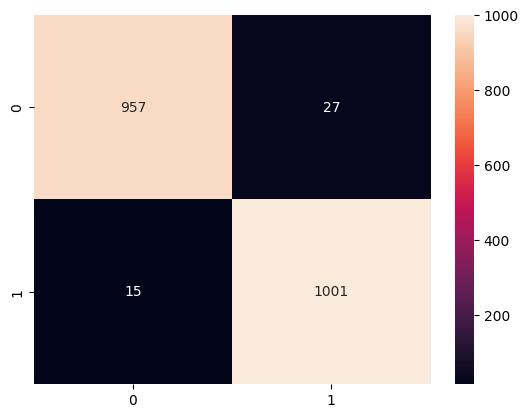

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(torch.Tensor(probs).numpy(), torch.Tensor(y_test_Tensor).numpy())
print(sns.heatmap(cm, annot=True, fmt="d"))

print(cm)

### Train - Test Loss Curve


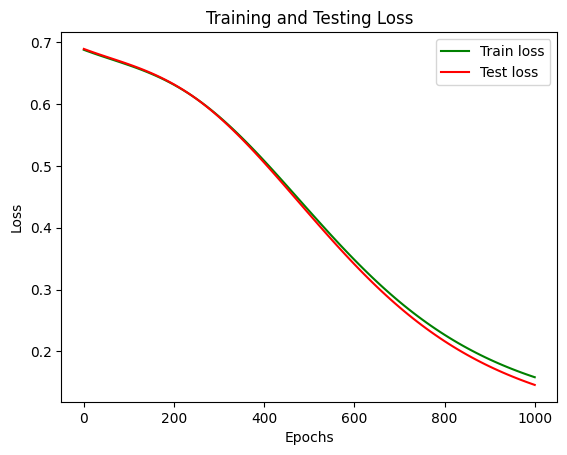

In [36]:
plt.plot(epochs_list, train_loss_list, c="g", label="Train loss")
plt.plot(epochs_list, test_loss_list, c="r", label="Test loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Testing Loss")
plt.legend()
plt.show()


In [53]:
print(X.columns)

Index(['session_frequency', 'session_duration', 'messages_sent',
       'days_since_last', 'start_emotion', 'end_emotion'],
      dtype='object')


### Saving the model to disk

In [ ]:
print(model.state_dict())

In [100]:
torch.save(model.state_dict(), "Dropout/dropout_model.pth")

Save the scaler paramaters as well for future input scaling


In [102]:
import joblib
joblib.dump(scaler, "Dropout/scaler.pkl")

['Dropout/scaler.pkl']